In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#-------------------- Imports and Environment Setup --------------------

import os
import sys
import time
import json
import copy
import numpy as np

import snntorch as snn
import torch

from snntorch import utils
from snntorch import spikegen

from torch.utils.data import DataLoader 
from torch import nn

import matplotlib.pyplot as plt
import seaborn as sns

import snntorch.spikeplot as splt
from IPython.display import HTML, display

home_dir = "../src"

sys.path.append(os.path.join(os.getcwd(), home_dir))

from main import *
from recurr_net import *
from visualize import *

import ipywidgets as widgets

#### load model

In [3]:
folder = '../src/checkpoints/SNNGraph_20261002_152504' 
print(os.listdir(folder))

['final_model.pt', 'history.json', 'best_model.pt', 'metadata.json']


In [4]:
model_path = "../src/checkpoints/SNNGraph_20260924_185616/final_model.pt"
meta_path = "../src/checkpoints/SNNGraph_20260924_185616/metadata.json"


with open(meta_path) as f:
    meta = json.load(f)
print(meta)

{'model_name': 'SNNGraph', 'timestamp': '20260924_185616', 'input_size': None, 'node_order': ['hidden', 'output'], 'node_inputs': {'hidden': ['input'], 'output': ['hidden']}, 'node_delayed': None, 'node_sizes': {'hidden': 1000, 'output': 10}, 'output_names': ['output'], 'num_steps': 25, 'tau': 17, 'total_iterations': 11725, 'best_test_acc': 0.953125, 'best_train_acc': 0.8984375, 'best_epoch': 20, 'best_iteration': 9700, 'final_test_acc': 0.8782, 'final_train_acc': 0.9113}


In [5]:
# Training Parameters
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
data_path='../src/data'
batch_size=128 # based on hardware constraints and dataset size, also adjust learning rate accordingly
num_steps=100

FASHION_MNIST_CLASSES = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot',
}

# Network Architecture
num_inputs = 28*28
num_hidden = 1000
num_outputs = 10

# Temporal Dynamics
num_steps = 25
beta = 0.95

# training parmeters 

learning_rate = 1e-3
num_epochs = 25

#-------------------- Load Dataset --------------------

train_loader, test_loader = load_dataset('fashion-mnist', root=data_path, batch_size=batch_size)

#-------------------- Neuron Initialization -------------------

lif1 = LeakySurrogate(beta=beta) 
lif2 = RLeakySurrogate (beta=beta, hidden_size=num_hidden)

In [6]:
node_specs=[
            ('hidden', {'inputs': ['input'], 'size': num_hidden, 'neuron_factory': lambda size: lif2}), #recurrent layer
            ('output', {'inputs': ['hidden'], 'size': num_outputs, 'neuron_factory': lambda size: lif1}), # output layer
        ]

model = SNNGraph(node_specs=node_specs,
        input_size=num_inputs,
        input_name='input',
        output_names=['output'],
        device=device
    ).to(device)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # any lr, gets overwritten if load_optimizer=True
loss = SF_temporal_rate_CE(tau=17, device=device)

modeler = Modeler(model, loss, optimizer, train_loader, test_loader, num_steps=meta['num_steps'], device=device)
checkpoint = modeler.load_checkpoint(os.path.join(folder, 'final_model.pt'), load_optimizer=True)


Loaded checkpoint from ../src/checkpoints/SNNGraph_20261002_152504/final_model.pt


#### visualize weights

In [8]:
def plot_weights(net):
    fig, axes = plt.subplots(1, len(net.nodes), figsize=(5*len(net.nodes), 4))
    if len(net.nodes) == 1: axes = [axes]
    for ax, (name, node) in zip(axes, net.nodes.items()):
        for proj in node.projections:
            w = proj.weight.detach().cpu().numpy()
            ax.hist(w.flatten(), bins=60, alpha=0.6)
        ax.set_title(f'{name} — projection weights')
        ax.set_xlabel('weight value')

    # recurrent V matrices, if any — heatmap so you can visually confirm the diagonal is zero
    for name, node in net.nodes.items():
        if hasattr(node.neuron, 'V'):
            V = (node.neuron.V).detach().cpu().numpy()
            plt.figure(figsize=(5, 5))
            plt.imshow(V, cmap='RdBu', vmin=-abs(V).max(), vmax=abs(V).max())
            plt.colorbar()
            plt.title(f'{name} — recurrent V (diagonal should be 0)')
    plt.show()

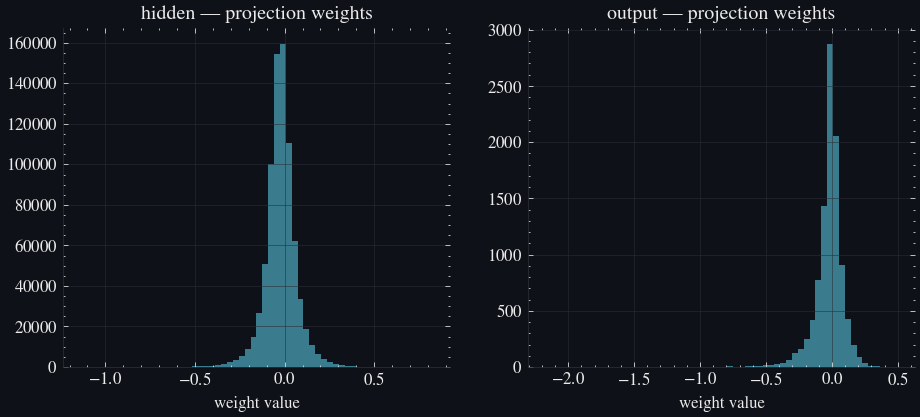

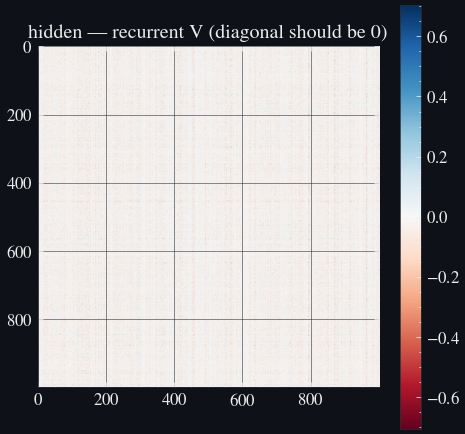

In [9]:
plot_weights(model)

In [10]:
def weightmaps(net, figsize_per_plot=(5, 4), max_neurons_shown=100):
    """
    Visualizes every LayerNode's weights in an SNNGraph:
      - feedforward/skip projection weights -> one heatmap per incoming edge
      - recurrent V (if present) -> one heatmap, with the masked-zero diagonal visible
    Large matrices are subsampled to max_neurons_shown x max_neurons_shown so the
    heatmap stays legible (annotated cells become unreadable past ~30-40 neurons anyway).
    """
    # collect all (title, matrix) pairs first, so we can lay out one shared figure
    panels = []
    for name, node in net.nodes.items():
        for i, proj in enumerate(node.projections):
            src_name = net.node_inputs[name][i] if i < len(net.node_inputs[name]) else f'edge{i}'
            w = proj.weight.detach().cpu().numpy()
            panels.append((f'{src_name} -> {name}\n{w.shape[1]}x{w.shape[0]}', w))

        if hasattr(node.neuron, 'V'):
            V = (node.neuron.V * node.neuron.mask).detach().cpu().numpy()
            panels.append((f'{name} recurrent V\n(diag masked to 0)', V))

    n = len(panels)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0]*ncols, figsize_per_plot[1]*nrows))
    axes = np.array(axes).reshape(-1)  # flatten regardless of shape

    for ax, (title, w) in zip(axes, panels):
        # subsample if too large to read
        if w.shape[0] > max_neurons_shown or w.shape[1] > max_neurons_shown:
            row_idx = np.linspace(0, w.shape[0]-1, min(w.shape[0], max_neurons_shown)).astype(int)
            col_idx = np.linspace(0, w.shape[1]-1, min(w.shape[1], max_neurons_shown)).astype(int)
            w_show = w[np.ix_(row_idx, col_idx)]
        else:
            w_show = w

        vmax = np.abs(w_show).max()
        sns.heatmap(w_show, ax=ax, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                    cbar=True, xticklabels=False, yticklabels=False)
        ax.set_title(title, fontsize=10)

    # hide any unused subplot slots
    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

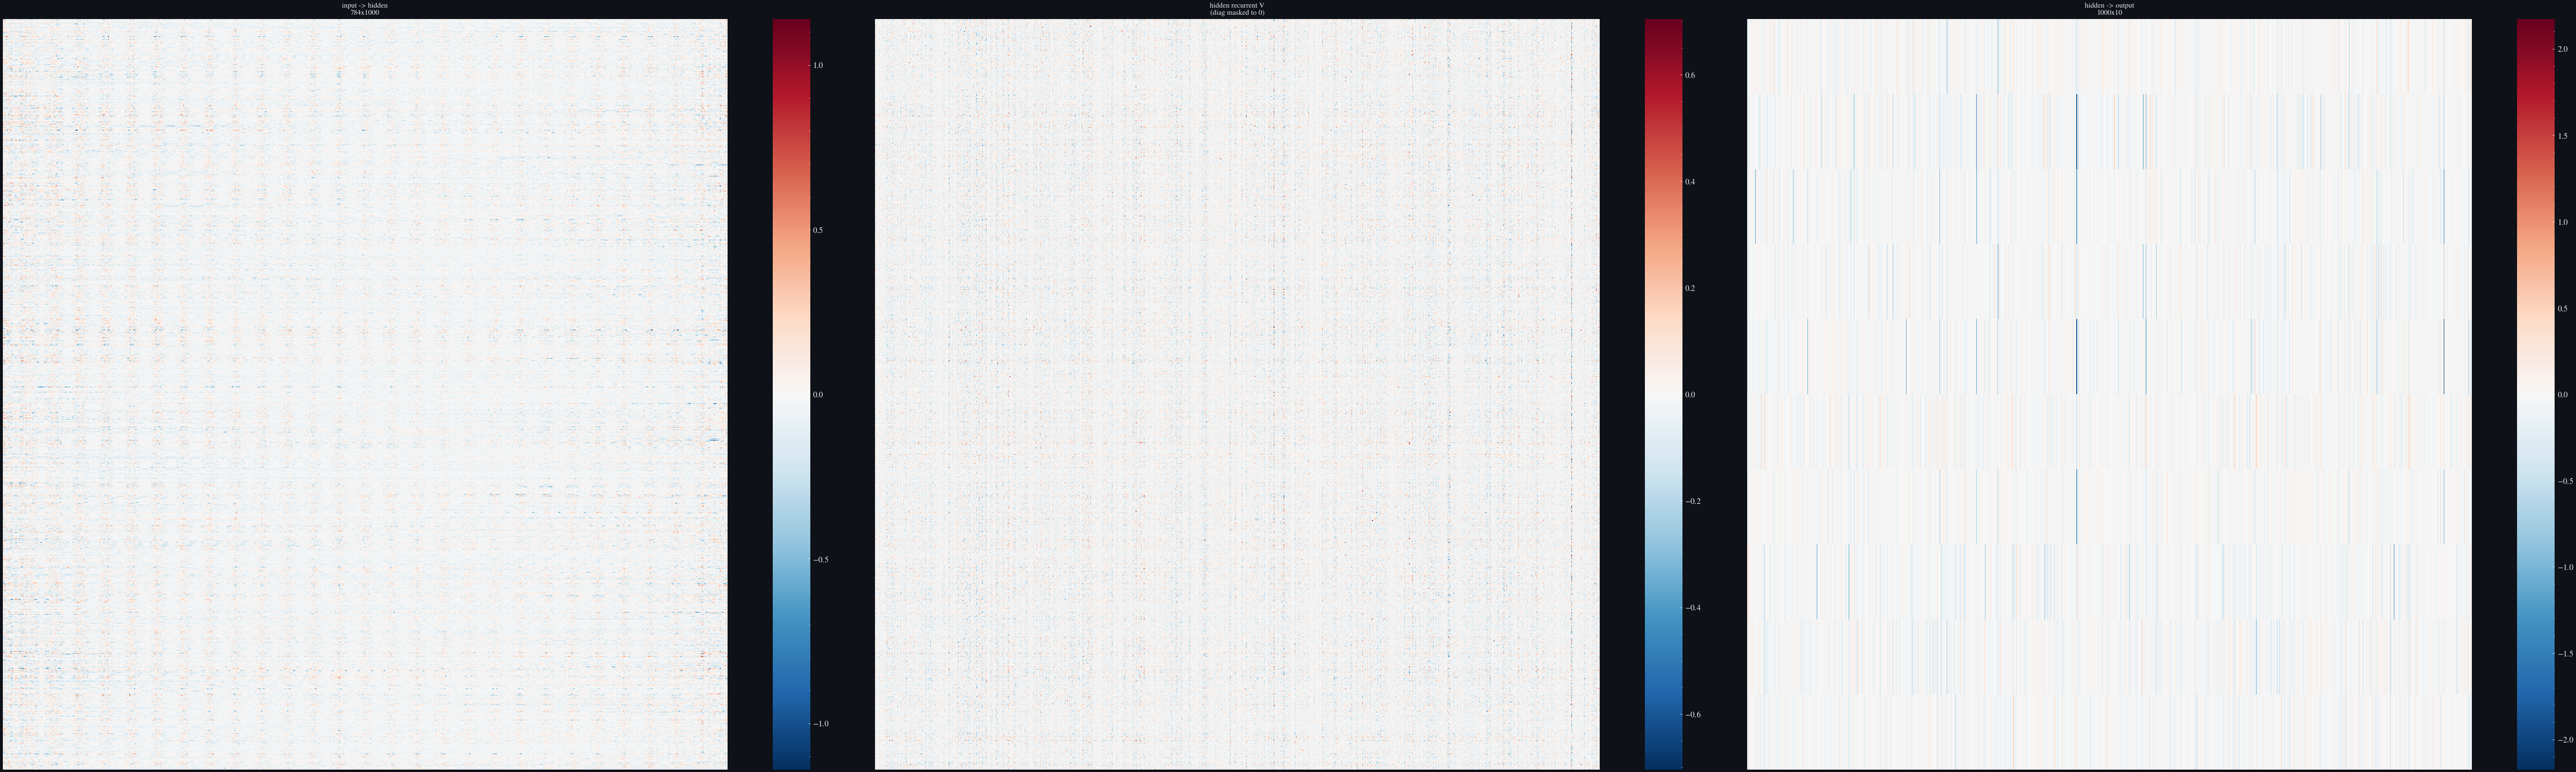

In [11]:
weightmaps(model, figsize_per_plot=(17, 15), max_neurons_shown=1000)

In [9]:
model.nodes['hidden'].neuron.V

Parameter containing:
tensor([[-0.0559,  0.1304,  0.0318,  ..., -0.0507,  0.0765, -0.0279],
        [-0.0314, -0.0059, -0.1365,  ..., -0.0370, -0.0886, -0.0311],
        [-0.0301, -0.0381,  0.0138,  ...,  0.0188, -0.0755,  0.0041],
        ...,
        [-0.0664, -0.0377,  0.0692,  ..., -0.0480, -0.0200, -0.0323],
        [ 0.0290,  0.0844,  0.0463,  ...,  0.0916, -0.0175,  0.0657],
        [-0.0573,  0.0145, -0.0345,  ...,  0.0114,  0.0027,  0.0225]],
       device='cuda:0', requires_grad=True)

In [10]:
modeler.final_model_evaluation(train_accuracy=True)

Final Test Set Accuracy: 87.85%
Final Train Set Accuracy: 90.84%


(0.8785, 0.9083666666666667)

In [11]:
print(type(modeler.net).__module__)
print(type(modeler.net))

recurr_net
<class 'recurr_net.SNNGraph'>


### Visualize testing and coding (visualize)


### Analysis (utils)

In [12]:
def selectncode(dataset, net, num_steps, device, idx=None):
    """
    Picks a random (or specific) sample from `dataset` (must have spikegen.latency-style
    access to raw data), encodes it, runs it through `net`, and returns everything
    you need for visualization in one bundle.
    """
    if idx is None:
        idx = np.random.randint(0, len(dataset) - 1)

    raw_data, target = dataset[idx]
    raw_data = raw_data.to(device).unsqueeze(0)  # add batch dim -> (1, 1, 28, 28) or similar

    spike_data = spikegen.latency(raw_data, num_steps=num_steps, normalize=True, clip=True)
    spike_data = spike_data.view(num_steps, 1, -1)  # (num_steps, batch=1, 784)

    net.eval()
    with torch.no_grad():
        spk_dict = net(spike_data, record_all=True)

    return {
        'idx': idx,
        'target': target,
        'input': spike_data,   # (num_steps, 1, 784)
        'spk_dict': spk_dict,       # {layer_name: (spk, mem)}
    }


def visualize_mnist(sample_dict, shape=(-1, 28, 28), visual_delay=200, label_dict=None):

    """

    - visual_delay
    """
    input_sample = sample['input']
    index = sample['idx']
    label = sample['target']

    #reshape
    input_sample = input_sample.view(shape)

        
    fig, ax = plt.subplots(facecolor='w', figsize=(5, 5))
    if label_dict is not None:
        ax.set_title(f"{index} : {label} : {label_dict[label]}")
    anim = splt.animator(input_sample, fig, ax, interval=visual_delay)
    return HTML(anim.to_html5_video())


def visual_output_raster(sample_dict, shape=(-1, 10)):

    input_sample = sample['input']
    index = sample['idx']
    label = sample['target']
    spike_dict = sample["spk_dict"]

    #  Index into a single sample from a minibatch
    spike_data_sample = spike_dict['output'][0].detach().cpu().view(shape)
    
    fig = plt.figure(facecolor="w", figsize=(10, 5))
    ax = fig.add_subplot(111)
    
    #  s: size of scatter points; c: color of scatter points
    splt.raster(spike_data_sample, ax)
    plt.title(f"output Layer, ")
    plt.xlabel("Time step")
    plt.ylabel("Neuron Number")
    plt.show()

In [30]:
sample = selectncode(modeler.test_loader.dataset, model, modeler.num_steps, device)

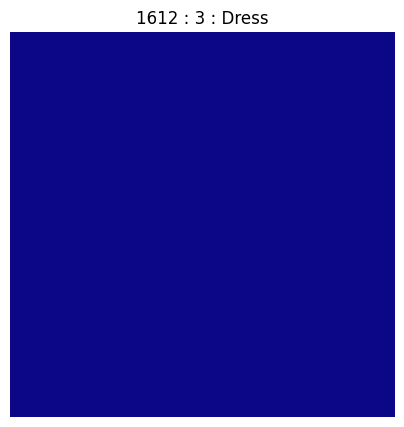

In [31]:
visualize_mnist(sample, visual_delay=500, label_dict=FASHION_MNIST_CLASSES)

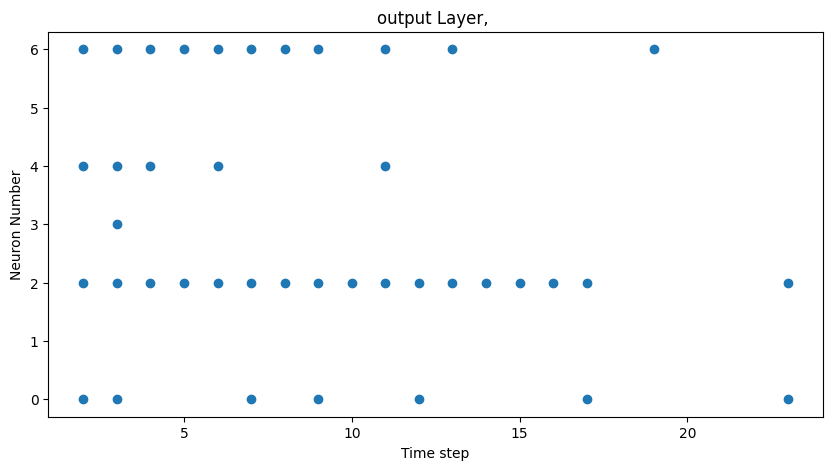

In [15]:
visual_output_raster(sample)

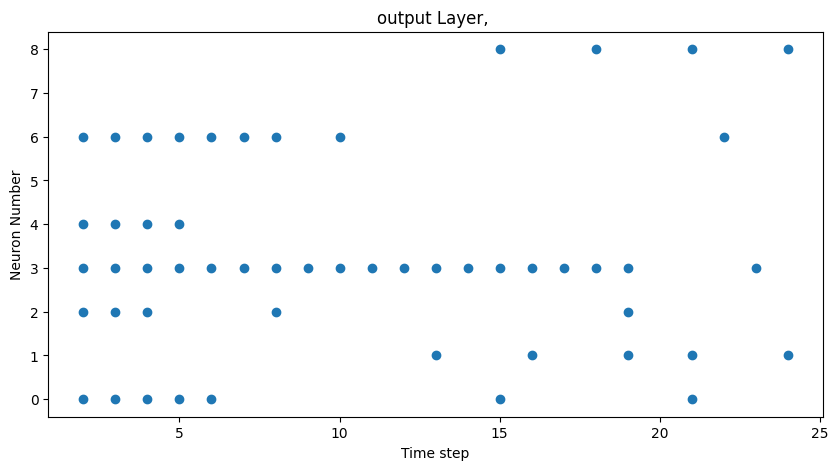

In [32]:
visual_output_raster(sample)

In [17]:
FASHION_MNIST_CLASSES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

In [36]:
visualize_snn_graph(sample, model, class_names=FASHION_MNIST_CLASSES)

In [35]:
pars = default_viz_pars()
pars = default_viz_pars(**{**pars, 'cmap_name': 'magma', 'spiking': False,})